# RandomForest HIV Classification with 5-Fold CV

This notebook evaluates the RandomForest model on the HIV dataset using Morgan fingerprints, stratified 5-fold cross-validation, fold-level validation/test splits, and summary statistics (mean, std, variance).

In [1]:

# If needed in Colab:
!pip -q install rdkit

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
RDLogger.DisableLog('rdApp.*')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 52.0 MB/s eta 0:00:00


In [2]:

SEED = 45
N_SPLITS = 5
VAL_SIZE_WITHIN_TEMP = 0.5  # temp set is split equally into val and test
RADIUS = 2
N_BITS = 2048

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

def smiles_to_morgan_fp(smiles_list, radius=2, n_bits=2048):
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
            fps.append(np.array(fp, dtype=np.float32))
        else:
            fps.append(np.zeros(n_bits, dtype=np.float32))
    return np.array(fps, dtype=np.float32)

def build_model(random_state):
    from sklearn.ensemble import RandomForestClassifier
    return RandomForestClassifier(
        n_estimators=100,
        random_state=random_state,
        n_jobs=-1
    )

def maybe_scale(X_train, X_val, X_test):
    return X_train, X_val, X_test


def evaluate_fold(model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score)
    }, y_score


In [3]:

df = pd.read_csv("https://raw.githubusercontent.com/McahitKutsal/hivcsv/main/HIV7.csv")
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

X = smiles_to_morgan_fp(df["smiles"], radius=RADIUS, n_bits=N_BITS)
y = df["HIV_active"].astype(int).values

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_results = []
roc_curves = []

for fold, (train_idx, temp_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n===== FOLD {fold} / {N_SPLITS} =====")
    set_seed(SEED + fold)

    X_train_full, y_train_full = X[train_idx], y[train_idx]
    X_temp, y_temp = X[temp_idx], y[temp_idx]

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=VAL_SIZE_WITHIN_TEMP,
        stratify=y_temp,
        random_state=SEED + fold
    )

    X_train, X_val, X_test = maybe_scale(X_train_full, X_val, X_test)

    model = build_model(random_state=SEED + fold)
    model.fit(X_train, y_train_full)

    metrics, y_score = evaluate_fold(model, X_test, y_test)
    fold_results.append({
        "fold": fold,
        "test_accuracy": metrics["accuracy"],
        "test_precision": metrics["precision"],
        "test_recall": metrics["recall"],
        "test_f1": metrics["f1"],
        "test_roc_auc": metrics["roc_auc"]
    })

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_curves.append((fold, fpr, tpr, metrics["roc_auc"]))

    print({k: round(v, 4) if isinstance(v, float) else v for k, v in fold_results[-1].items()})

results_df = pd.DataFrame(fold_results)
results_df



===== FOLD 1 / 5 =====
{'fold': 1, 'test_accuracy': 0.8512, 'test_precision': 0.9268, 'test_recall': 0.7703, 'test_f1': 0.8413, 'test_roc_auc': np.float64(0.9182)}

===== FOLD 2 / 5 =====
{'fold': 2, 'test_accuracy': 0.8824, 'test_precision': 0.9672, 'test_recall': 0.7973, 'test_f1': 0.8741, 'test_roc_auc': np.float64(0.949)}

===== FOLD 3 / 5 =====
{'fold': 3, 'test_accuracy': 0.8581, 'test_precision': 0.935, 'test_recall': 0.777, 'test_f1': 0.8487, 'test_roc_auc': np.float64(0.925)}

===== FOLD 4 / 5 =====
{'fold': 4, 'test_accuracy': 0.9135, 'test_precision': 0.9692, 'test_recall': 0.8571, 'test_f1': 0.9097, 'test_roc_auc': np.float64(0.9493)}

===== FOLD 5 / 5 =====
{'fold': 5, 'test_accuracy': 0.8201, 'test_precision': 0.9204, 'test_recall': 0.7075, 'test_f1': 0.8, 'test_roc_auc': np.float64(0.8953)}


,fold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,1,0.851211,0.926829,0.770270,0.841328,0.918200
1,2,0.882353,0.967213,0.797297,0.874074,0.948989
2,3,0.858131,0.934959,0.777027,0.848708,0.925029
3,4,0.913495,0.969231,0.857143,0.909747,0.949267
4,5,0.820069,0.920354,0.707483,0.800000,0.895348


In [4]:

summary_rows = []
for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std(ddof=1)
    var_val = results_df[metric].var(ddof=1)
    summary_rows.append({
        "Metric": metric.replace("test_", "").upper(),
        "Mean": mean_val,
        "Std": std_val,
        "Variance": var_val,
        "Formatted": f"{mean_val:.4f} ± {std_val:.4f}"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Metric,Mean,Std,Variance,Formatted
0,ACCURACY,0.865052,0.035032,0.001227,0.8651 ± 0.0350
1,PRECISION,0.943717,0.022971,0.000528,0.9437 ± 0.0230
2,RECALL,0.781844,0.053841,0.002899,0.7818 ± 0.0538
3,F1,0.854772,0.040658,0.001653,0.8548 ± 0.0407
4,ROC_AUC,0.927367,0.022704,0.000515,0.9274 ± 0.0227


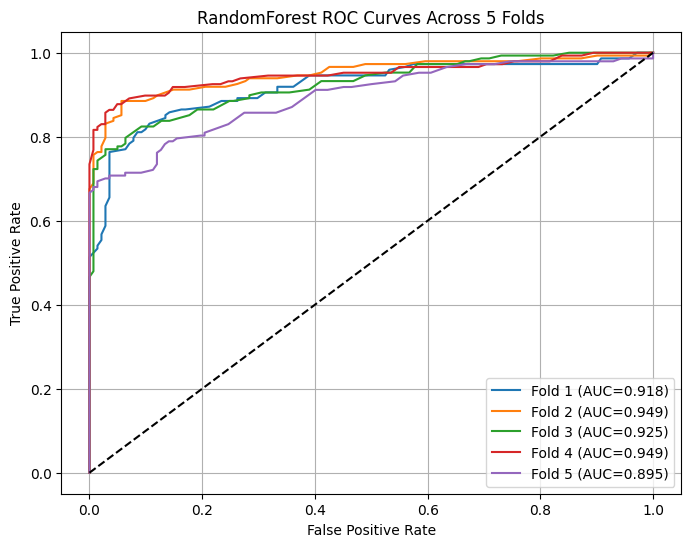

In [5]:

plt.figure(figsize=(8, 6))
for fold, fpr, tpr, auc_val in roc_curves:
    plt.plot(fpr, tpr, label=f"Fold {fold} (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RandomForest ROC Curves Across 5 Folds")
plt.legend()
plt.grid(True)
plt.show()


In [6]:

results_df.to_csv("RandomForest_fold_results.csv", index=False)
summary_df.to_csv("RandomForest_summary_results.csv", index=False)

print("Saved:")
print("- RandomForest_fold_results.csv")
print("- RandomForest_summary_results.csv")


Saved:
- RandomForest_fold_results.csv
- RandomForest_summary_results.csv


Saved: RF_oof_predictions.csv


,fold,smiles,y_true,y_pred,y_prob
0,1,Clc1ccc2nsnc2c1,0,0,0.106667
1,1,Nc1ccc(C=Cc2ccc(NC(=O)c3cc(S(=O)(=O)O)c4cccnc4...,1,1,1.000000
2,1,CCCCCCCCCCNCCSSCc1ccccc1,0,0,0.400000
3,1,O=S(=O)(O)CC(O)CN(CCO)CCO,0,0,0.040000
4,1,COC(=O)C1C2CCC3(C)C(OC(C)=O)CCC3C2CCC1C1(C)SCCS1,1,1,0.500000


Saved: RF_top_10_candidates.csv  |  Top rows: 10


,fold,smiles,y_true,y_pred,y_prob
0,3,COc1cc(N=Nc2cc(NC(C)=O)c(N=Nc3ccc(S(=O)(=O)O)c...,1,1,1.0
1,3,O=C(Nc1ccc(C=Cc2ccc(NC(=O)c3ccc(N=Nc4cc(S(=O)(...,1,1,1.0
2,3,Nc1c(N=Nc2ccc(S(=O)(=O)c3ccc(N=Nc4cc(S(=O)(=O)...,1,1,1.0
3,3,Cc1cn(C2CC(N=[N+]=[N-])C(COC(=O)CCCCCCCCCCBr)O...,1,1,1.0
4,3,CCCCCCCCCCCCCCCCCCCCCCNc1ccn(C2CC(OP(=O)(O)OCC...,1,1,1.0
5,3,Cc1cc(N=Nc2ccc(NC(=O)c3ccc(N)cc3)cc2C)ccc1N=Nc...,1,1,1.0
6,3,CC(C)CCCC(C)C1CCC2C3CCC4CC(CCC=C(c5cc(Cl)c(OCc...,1,1,1.0
7,3,Cc1cn(C2CC(N=[N+]=[N-])C(COP(=O)(OCC(=O)c3cccc...,1,1,1.0
8,5,CCc1c(Cc2cc(C)cc(C)c2)n(COCCC[Se]c2ccccc2)c(=O...,1,1,1.0
9,5,CCCC1OCC2OC(n3cc(C)c(=O)[nH]c3=O)CC2N1O,1,1,1.0


Saved: RF_top_10_descriptors.csv


,MW,LogP,HBD,HBA,TPSA,RotatableBonds,QED,fold,smiles,y_true,y_pred,y_prob
0,829.874,8.85314,5,15,285.58,13,0.042405,3,COc1cc(N=Nc2cc(NC(C)=O)c(N=Nc3ccc(S(=O)(=O)O)c...,1,1,1.0
1,1105.068,8.03830,8,18,391.36,14,0.022081,3,O=C(Nc1ccc(C=Cc2ccc(NC(=O)c3ccc(N=Nc4cc(S(=O)(...,1,1,1.0
2,900.905,5.15930,6,16,353.10,10,0.044731,3,Nc1c(N=Nc2ccc(S(=O)(=O)c3ccc(N=Nc4cc(S(=O)(=O)...,1,1,1.0
3,514.421,4.26042,1,6,139.15,14,0.098699,3,Cc1cn(C2CC(N=[N+]=[N-])C(COC(=O)CCCCCCCCCCBr)O...,1,1,1.0
4,1138.208,8.57249,6,17,351.39,37,0.010341,3,CCCCCCCCCCCCCCCCCCCCCCNc1ccn(C2CC(OP(=O)(O)OCC...,1,1,1.0


Saved: RF_docking_candidates_filtered.csv


,MW,LogP,HBD,HBA,TPSA,RotatableBonds,QED,fold,smiles,y_true,y_pred,y_prob,Lipinski_pass
8,485.486,3.11884,1,3,64.09,10,0.354692,5,CCc1c(Cc2cc(C)cc(C)c2)n(COCCC[Se]c2ccccc2)c(=O...,1,1,1.0,True
9,311.338,0.34872,2,6,96.79,3,0.835837,5,CCCC1OCC2OC(n3cc(C)c(=O)[nH]c3=O)CC2N1O,1,1,1.0,True


Saved: RF_final_2_candidates.csv
Saved: RF_docking_input.smi


,smiles,y_prob,QED,MW,LogP
9,CCCC1OCC2OC(n3cc(C)c(=O)[nH]c3=O)CC2N1O,1.0,0.835837,311.338,0.34872
8,CCc1c(Cc2cc(C)cc(C)c2)n(COCCC[Se]c2ccccc2)c(=O...,1.0,0.354692,485.486,3.11884


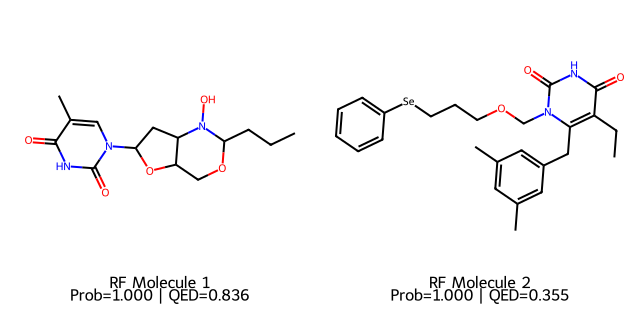


Summary
-------
Total OOF predictions          : 1434
Unique ranked molecules        : 1434
Top active candidates exported : 10
Lipinski-passing candidates    : 2
Final docking candidates       : 2


In [7]:

# =========================================================
# RF DOCKING PREPARATION: OOF PREDICTIONS + TOP-2 CANDIDATES
# =========================================================

from rdkit.Chem import Descriptors, Lipinski, Crippen, QED, Draw

# 1) Build out-of-fold (OOF) prediction table using the same 5-fold protocol
oof_rows = []

for fold, (train_idx, temp_idx) in enumerate(skf.split(X, y), start=1):
    set_seed(SEED + fold)

    X_train_full, y_train_full = X[train_idx], y[train_idx]
    X_temp, y_temp = X[temp_idx], y[temp_idx]
    smiles_temp = df.iloc[temp_idx]["smiles"].reset_index(drop=True)

    _, X_test, _, y_test = train_test_split(
        X_temp, y_temp,
        test_size=VAL_SIZE_WITHIN_TEMP,
        stratify=y_temp,
        random_state=SEED + fold
    )

    # Recover smiles for the selected test split by repeating the same split on smiles
    _, smiles_test, _, _ = train_test_split(
        smiles_temp,
        y_temp,
        test_size=VAL_SIZE_WITHIN_TEMP,
        stratify=y_temp,
        random_state=SEED + fold
    )

    X_train, _, X_test = maybe_scale(X_train_full, X_test, X_test)

    rf_model = build_model(random_state=SEED + fold)
    rf_model.fit(X_train, y_train_full)

    y_prob = rf_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    fold_df = pd.DataFrame({
        "fold": fold,
        "smiles": list(smiles_test),
        "y_true": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob
    })
    oof_rows.append(fold_df)

oof_pred_df = pd.concat(oof_rows, ignore_index=True)
oof_pred_df = oof_pred_df.drop_duplicates(subset=["smiles"]).reset_index(drop=True)
oof_pred_df.to_csv("RF_oof_predictions.csv", index=False)

print("Saved: RF_oof_predictions.csv")
display(oof_pred_df.head())


# 2) Rank molecules by RF confidence
top_df = (
    oof_pred_df[oof_pred_df["y_pred"] == 1]
    .sort_values(by="y_prob", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_df.to_csv("RF_top_10_candidates.csv", index=False)
print("Saved: RF_top_10_candidates.csv  |  Top rows:", len(top_df))
display(top_df)


# 3) Compute descriptors
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "QED": QED.qed(mol)
    }

desc_rows = []
for _, row in top_df.iterrows():
    desc = compute_descriptors(row["smiles"])
    if desc is not None:
        desc.update(row.to_dict())
        desc_rows.append(desc)

desc_df = pd.DataFrame(desc_rows)
desc_df.to_csv("RF_top_10_descriptors.csv", index=False)
print("Saved: RF_top_10_descriptors.csv")
display(desc_df.head())


# 4) Drug-likeness filter
filtered_df = desc_df[
    (desc_df["MW"] <= 500) &
    (desc_df["LogP"] <= 5) &
    (desc_df["HBD"] <= 5) &
    (desc_df["HBA"] <= 10)
].copy()

filtered_df["Lipinski_pass"] = True
filtered_df.to_csv("RF_docking_candidates_filtered.csv", index=False)
print("Saved: RF_docking_candidates_filtered.csv")
display(filtered_df)


# 5) Select the final TOP-2 candidates
# Priority: QED first, then RF probability
final_df = filtered_df.sort_values(by=["QED", "y_prob"], ascending=False).head(2).copy()

if len(final_df) < 2:
    print("Warning: fewer than 2 Lipinski-passing molecules were found. Falling back to top-ranked filtered rows.")
    final_df = filtered_df.sort_values(by=["y_prob"], ascending=False).head(2).copy()

final_df.to_csv("RF_final_2_candidates.csv", index=False)
final_df["smiles"].to_csv("RF_docking_input.smi", index=False, header=False)

print("Saved: RF_final_2_candidates.csv")
print("Saved: RF_docking_input.smi")
display(final_df[["smiles", "y_prob", "QED", "MW", "LogP"]])


# 6) Draw only the final 2 molecules
best_smiles = final_df["smiles"].tolist()
best_mols = [Chem.MolFromSmiles(sm) for sm in best_smiles]

legends = []
for i, (_, row) in enumerate(final_df.iterrows(), start=1):
    legends.append(f"RF Molecule {i}\nProb={row['y_prob']:.3f} | QED={row['QED']:.3f}")

img = Draw.MolsToGridImage(
    best_mols,
    molsPerRow=2,
    subImgSize=(320, 320),
    legends=legends
)
display(img)

print("\nSummary")
print("-------")
print(f"Total OOF predictions          : {len(oof_pred_df)}")
print(f"Unique ranked molecules        : {oof_pred_df['smiles'].nunique()}")
print(f"Top active candidates exported : {len(top_df)}")
print(f"Lipinski-passing candidates    : {len(filtered_df)}")
print(f"Final docking candidates       : {len(final_df)}")


Saved: RF_oof_predictions.csv


,fold,smiles,y_true,y_pred,y_prob
0,1,Clc1ccc2nsnc2c1,0,0,0.106667
1,1,Nc1ccc(C=Cc2ccc(NC(=O)c3cc(S(=O)(=O)O)c4cccnc4c3O)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1.[NaH],1,1,1.000000
2,1,CCCCCCCCCCNCCSSCc1ccccc1,0,0,0.400000
3,1,O=S(=O)(O)CC(O)CN(CCO)CCO,0,0,0.040000
4,1,COC(=O)C1C2CCC3(C)C(OC(C)=O)CCC3C2CCC1C1(C)SCCS1,1,1,0.500000


Saved: RF_top_10_candidates.csv  |  Top rows: 10


,fold,smiles,y_true,y_pred,y_prob
0,3,COc1cc(N=Nc2cc(NC(C)=O)c(N=Nc3ccc(S(=O)(=O)O)cc3)cc2S(=O)(=O)O)c(C)cc1N=Nc1cc(OC)c(NC(=O)c2ccc(N)cc2)cc1C,1,1,1.0
1,3,O=C(Nc1ccc(C=Cc2ccc(NC(=O)c3ccc(N=Nc4cc(S(=O)(=O)O)c5cccnc5c4O)cc3)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1)c1ccc(N=Nc2cc(S(=O)(=O)O)c3cccnc3c2O)cc1.[NaH],1,1,1.0
2,3,Nc1c(N=Nc2ccc(S(=O)(=O)c3ccc(N=Nc4cc(S(=O)(=O)O)c5cccc(S(=O)(=O)O)c5c4N)cc3)cc2)cc(S(=O)(=O)O)c2cccc(S(=O)(=O)O)c12.[NaH],1,1,1.0
3,3,Cc1cn(C2CC(N=[N+]=[N-])C(COC(=O)CCCCCCCCCCBr)O2)c(=O)[nH]c1=O,1,1,1.0
4,3,CCCCCCCCCCCCCCCCCCCCCCNc1ccn(C2CC(OP(=O)(O)OCC3OC(n4cc(C)c(=O)[nH]c4=O)CC3N=[N+]=[N-])C(COP(=O)(O)OCC3CCC(n4ccc(=N)[nH]c4=O)O3)O2)c(=O)n1,1,1,1.0
5,3,Cc1cc(N=Nc2ccc(NC(=O)c3ccc(N)cc3)cc2C)ccc1N=Nc1ccc2c(O)c(N=Nc3ccc(S(=O)(=O)O)cc3)c(S(=O)(=O)O)cc2c1,1,1,1.0
6,3,CC(C)CCCC(C)C1CCC2C3CCC4CC(CCC=C(c5cc(Cl)c(OCc6ccc([N+](=O)[O-])cc6)c(C(=O)O)c5)c5cc(Cl)c(OCc6ccc([N+](=O)[O-])cc6)c(C(=O)O)c5)CCC4(C)C3CCC12C.[NaH],1,1,1.0
7,3,Cc1cn(C2CC(N=[N+]=[N-])C(COP(=O)(OCC(=O)c3ccccc3)OCC(=O)c3ccccc3)O2)c(=O)[nH]c1=O,1,1,1.0
8,5,CCc1c(Cc2cc(C)cc(C)c2)n(COCCC[Se]c2ccccc2)c(=O)[nH]c1=O,1,1,1.0
9,5,CCCC1OCC2OC(n3cc(C)c(=O)[nH]c3=O)CC2N1O,1,1,1.0


Saved: RF_top_10_descriptors.csv


...

Saved: RF_docking_candidates_filtered.csv


,MW,LogP,HBD,HBA,TPSA,RotatableBonds,QED,fold,smiles,y_true,y_pred,y_prob,Lipinski_pass
8,485.486,3.11884,1,3,64.09,10,0.354692,5,CCc1c(Cc2cc(C)cc(C)c2)n(COCCC[Se]c2ccccc2)c(=O)[nH]c1=O,1,1,1.0,True
9,311.338,0.34872,2,6,96.79,3,0.835837,5,CCCC1OCC2OC(n3cc(C)c(=O)[nH]c3=O)CC2N1O,1,1,1.0,True


Saved: RF_final_2_candidates.csv
Saved: RF_docking_input.smi


,smiles,y_prob,QED,MW,LogP
9,CCCC1OCC2OC(n3cc(C)c(=O)[nH]c3=O)CC2N1O,1.0,0.835837,311.338,0.34872
8,CCc1c(Cc2cc(C)cc(C)c2)n(COCCC[Se]c2ccccc2)c(=O)[nH]c1=O,1.0,0.354692,485.486,3.11884



FULL SMILES (FINAL 2):
1. CCCC1OCC2OC(n3cc(C)c(=O)[nH]c3=O)CC2N1O
2. CCc1c(Cc2cc(C)cc(C)c2)n(COCCC[Se]c2ccccc2)c(=O)[nH]c1=O


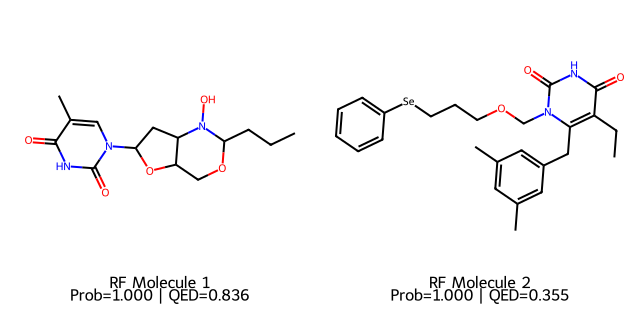


Summary
-------
Total OOF predictions          : 1434
Unique ranked molecules        : 1434
Top active candidates exported : 10
Lipinski-passing candidates    : 2
Final docking candidates       : 2


In [8]:
# =========================================================
# RF DOCKING PREPARATION: OOF PREDICTIONS + TOP-2 CANDIDATES
# (FULL SMILES DISPLAY FIXED VERSION)
# =========================================================

import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen, QED, Draw

# 🔴 SMILES kesilmesini engelle
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# 1) Build out-of-fold (OOF) prediction table
oof_rows = []

for fold, (train_idx, temp_idx) in enumerate(skf.split(X, y), start=1):
    set_seed(SEED + fold)

    X_train_full, y_train_full = X[train_idx], y[train_idx]
    X_temp, y_temp = X[temp_idx], y[temp_idx]
    smiles_temp = df.iloc[temp_idx]["smiles"].reset_index(drop=True)

    _, X_test, _, y_test = train_test_split(
        X_temp, y_temp,
        test_size=VAL_SIZE_WITHIN_TEMP,
        stratify=y_temp,
        random_state=SEED + fold
    )

    _, smiles_test, _, _ = train_test_split(
        smiles_temp,
        y_temp,
        test_size=VAL_SIZE_WITHIN_TEMP,
        stratify=y_temp,
        random_state=SEED + fold
    )

    X_train, _, X_test = maybe_scale(X_train_full, X_test, X_test)

    rf_model = build_model(random_state=SEED + fold)
    rf_model.fit(X_train, y_train_full)

    y_prob = rf_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    fold_df = pd.DataFrame({
        "fold": fold,
        "smiles": list(smiles_test),
        "y_true": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob
    })
    oof_rows.append(fold_df)

oof_pred_df = pd.concat(oof_rows, ignore_index=True)
oof_pred_df = oof_pred_df.drop_duplicates(subset=["smiles"]).reset_index(drop=True)
oof_pred_df.to_csv("RF_oof_predictions.csv", index=False)

print("Saved: RF_oof_predictions.csv")
display(oof_pred_df.head())


# 2) Rank molecules
top_df = (
    oof_pred_df[oof_pred_df["y_pred"] == 1]
    .sort_values(by="y_prob", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_df.to_csv("RF_top_10_candidates.csv", index=False)
print("Saved: RF_top_10_candidates.csv  |  Top rows:", len(top_df))
display(top_df)


# 3) Compute descriptors
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "QED": QED.qed(mol)
    }

desc_rows = []
for _, row in top_df.iterrows():
    desc = compute_descriptors(row["smiles"])
    if desc is not None:
        desc.update(row.to_dict())
        desc_rows.append(desc)

desc_df = pd.DataFrame(desc_rows)
desc_df.to_csv("RF_top_10_descriptors.csv", index=False)
print("Saved: RF_top_10_descriptors.csv")
display(desc_df.head())


# 4) Drug-likeness filter
filtered_df = desc_df[
    (desc_df["MW"] <= 500) &
    (desc_df["LogP"] <= 5) &
    (desc_df["HBD"] <= 5) &
    (desc_df["HBA"] <= 10)
].copy()

filtered_df["Lipinski_pass"] = True
filtered_df.to_csv("RF_docking_candidates_filtered.csv", index=False)
print("Saved: RF_docking_candidates_filtered.csv")
display(filtered_df)


# 5) Final TOP-2
final_df = filtered_df.sort_values(by=["QED", "y_prob"], ascending=False).head(2).copy()

if len(final_df) < 2:
    print("Warning: fallback used.")
    final_df = filtered_df.sort_values(by=["y_prob"], ascending=False).head(2).copy()

final_df.to_csv("RF_final_2_candidates.csv", index=False)
final_df["smiles"].to_csv("RF_docking_input.smi", index=False, header=False)

print("Saved: RF_final_2_candidates.csv")
print("Saved: RF_docking_input.smi")

display(final_df[["smiles", "y_prob", "QED", "MW", "LogP"]])


# 🔥 FULL SMILES PRINT (KESİLMEDEN)
print("\nFULL SMILES (FINAL 2):")
for i, smi in enumerate(final_df["smiles"], start=1):
    print(f"{i}. {smi}")


# 6) Draw molecules
best_smiles = final_df["smiles"].tolist()
best_mols = [Chem.MolFromSmiles(sm) for sm in best_smiles]

legends = []
for i, (_, row) in enumerate(final_df.iterrows(), start=1):
    legends.append(f"RF Molecule {i}\nProb={row['y_prob']:.3f} | QED={row['QED']:.3f}")

img = Draw.MolsToGridImage(
    best_mols,
    molsPerRow=2,
    subImgSize=(320, 320),
    legends=legends
)
display(img)


print("\nSummary")
print("-------")
print(f"Total OOF predictions          : {len(oof_pred_df)}")
print(f"Unique ranked molecules        : {oof_pred_df['smiles'].nunique()}")
print(f"Top active candidates exported : {len(top_df)}")
print(f"Lipinski-passing candidates    : {len(filtered_df)}")
print(f"Final docking candidates       : {len(final_df)}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')